# Agentic Multimodal Demo

This notebook is organized as a set of independent demo sections.

Run **Setup** first. After that, run one demo section at a time:

1. Animal poster
2. People / series posters
3. Labeled maps
4. Great-circle flight path

The core idea is decomposition: use structured data to choose subjects, generate or fetch images one subject at a time, and render labels/layout with normal Python code.


## 0. Setup

This cell finds the repo root, adds the package to `sys.path`, imports the main helpers, and builds the registry.


In [1]:
from pathlib import Path
import sys
import os
import math
import numpy as np

def find_repo_root(start: Path = Path.cwd()) -> Path:
    current = start.resolve()
    for path in [current, *current.parents]:
        if (path / ".git").exists():
            return path
    raise RuntimeError("Could not find repo root. Open this notebook from inside the repo.")

REPO_ROOT = find_repo_root()

SRC_ROOT = REPO_ROOT / "src"
sys.path.insert(0, str(SRC_ROOT))
sys.path.insert(0, str(SRC_ROOT / "genai_demos"))

from agentic_multimodal.core.config import CACHE, RESULTS, SRC
from agentic_multimodal.services.registry import make_registry

from agentic_multimodal.skills.adapters import (
    countries_to_mapspec,
    image_from_flag_url,
    image_from_pick_url,
    label_country,
    label_country_plus_pick,
    name_year_pairs,
    render_portraits_for_picks,
)

from agentic_multimodal.skills.image_gen import (
    batch_generate_subject_images,
    generate_person_images,
)
from agentic_multimodal.skills.image_prompts import subject_portrait
from agentic_multimodal.notebook_utils import display_image

from support import tree_markdown

reg = make_registry(REPO_ROOT)

for directory in [CACHE, RESULTS]:
    directory.mkdir(parents=True, exist_ok=True)

print("Repo root:", REPO_ROOT)
print("Package src:", SRC)


/opt/anaconda3/envs/ai_py312/lib/python3.12/site-packages/bitsandbytes/cextension.py:34: UserWarning: The installed version of bitsandbytes was compiled without GPU support. 8-bit optimizers, 8-bit multiplication, and GPU quantization are unavailable.
  warn("The installed version of bitsandbytes was compiled without GPU support. "


'NoneType' object has no attribute 'cadam32bit_grad_fp32'
Repo root: /Users/douglasdaly/GitHub/Generative-AI
Package src: /Users/douglasdaly/GitHub/Generative-AI/src/genai_demos/agentic_multimodal


### Register notebook adapters

These assignments keep older graph code and notebook examples compatible with the registry object.


In [2]:
reg.adapters.countries_to_mapspec = countries_to_mapspec
reg.adapters.image_from_flag = image_from_flag_url
reg.adapters.image_from_pick = image_from_pick_url
reg.adapters.label_country = label_country
reg.adapters.label_country_plus_pick = label_country_plus_pick
reg.adapters.render_portraits_for_picks = render_portraits_for_picks


### Optional: show package tree


In [3]:
display(tree_markdown(SRC))


```agentic_multimodal/
├── assets
│   ├── catalogs
│   │   └── group_items
│   │       ├── animals.json
│   │       ├── flowers.json
│   │       └── plants.json
│   ├── ne
│   │   ├── ne_110m_admin_0_countries.geojson
│   │   └── ne_50m_admin_0_countries.geojson
│   └── prompts
│       └── overrides.yaml
├── cache
├── core
│   ├── __init__.py
│   └── config.py
├── graphs
│   ├── __init__.py
│   ├── factory.py
│   ├── geo_flow.py
│   ├── group_poster_flow.py
│   └── person_flow.py
├── schemas
│   ├── __init__.py
│   ├── artifacts.py
│   ├── entities.py
│   ├── messages.py
│   └── requests.py
├── services
│   ├── cache.py
│   ├── io_web_fetcher.py
│   ├── llm_factory.py
│   ├── registry.py
│   └── settings.py
├── skills
│   ├── adapters
│   │   ├── __init__.py
│   │   ├── countries_to_map.py
│   │   ├── items_to_poster.py
│   │   ├── people_to_poster.py
│   │   └── picks_to_portraits.py
│   ├── data
│   │   ├── __init__.py
│   │   ├── group_item_catalog.py
│   │   ├── natural_earth.py
│   │   ├── wd_utils.py
│   │   ├── wiki_pageviews.py
│   │   ├── wikidata_geo.py
│   │   ├── wikidata_search_label.py
│   │   ├── wikidata_series.py
│   │   ├── wikidata_sparql.py
│   │   ├── wikidata_taxa.py
│   │   ├── wikimedia_cache.py
│   │   └── wikipedia_category_members.py
│   ├── geo
│   │   ├── __init__.py
│   │   ├── aliases.py
│   │   ├── europe_flags.py
│   │   ├── flight_path.py
│   │   ├── region_flags.py
│   │   └── subdivisions.py
│   ├── selectors
│   │   ├── __init__.py
│   │   └── famous_by_country.py
│   ├── series
│   │   ├── __init__.py
│   │   ├── aliases.py
│   │   ├── award.py
│   │   ├── candidates.py
│   │   ├── group_items.py
│   │   ├── per_country.py
│   │   ├── positions.py
│   │   └── rankers.py
│   ├── __init__.py
│   ├── gen_map_renderer.py
│   ├── gen_poster_renderer.py
│   ├── image_gen.py
│   ├── image_prompts.py
│   └── map_regions.py
├── __init__.py
└── notebook_utils.py
```

## 1. Animal poster

This section builds a poster the robust way:

1. Select named animals from structured data.
2. Build one prompt per animal.
3. Generate one image per animal.
4. Render labels and grid layout with Python.

This avoids the common failure mode where a single prompt like "make a poster of 100 animals" produces unreadable text, duplicate animals, or nonsensical labels.


In [4]:
from agentic_multimodal.skills.series.group_items import get_group_items
from agentic_multimodal.skills.adapters.items_to_poster import (
    ANIMAL_NEGATIVE_PROMPT,
    group_items_to_image_picks,
    group_items_to_posterspec,
)

ANIMAL_COUNT = 10
ANIMAL_SEED = "animals_mix_v1"
ANIMAL_IMAGE_DIR = f"artifacts/animals_portraits_{ANIMAL_COUNT}"
ANIMAL_POSTER_PATH = f"artifacts/poster_animals_{ANIMAL_COUNT}_mixed.webp"

# Use smaller settings while testing. Raise size/steps later if desired.
IMAGE_SIZE = (512, 512)
STEPS = 24
BATCH_SIZE = 5


### 1A. Select animal subjects


In [5]:
items = get_group_items(
    reg,
    item_type="animals",
    count=ANIMAL_COUNT,
    seed=ANIMAL_SEED,
    force_rebuild=False,
)

counts = {
    group: sum(1 for item in items if item.get("group") == group)
    for group in sorted({item.get("group") for item in items})
}

print("Counts:", counts)
print("Sample:", [item["display"] for item in items[:8]])


Counts: {'bird': 4, 'mammal': 4, 'reptile': 2}
Sample: ['North American cougar', 'Pacific Water Shrew', 'White-backed Hog-nosed Skunk', 'Southern broad-footed mole', 'Dark-eyed Junco', 'American Goldfinch', 'Fish Crow', 'Northern Bobwhite']


### 1B. Generate one image per animal

`skip_existing=True` makes this resumable. If the run stops partway through, re-run the cell and it will reuse images that already exist.


In [6]:
if 0:
    picks = group_items_to_image_picks(items)

    paths = batch_generate_subject_images(
        picks,
        outdir=ANIMAL_IMAGE_DIR,
        batch_size=BATCH_SIZE,
        size=IMAGE_SIZE,
        steps=STEPS,
        cfg=6.0,
        seed=1337,
        skip_existing=True,
        negative_prompt=ANIMAL_NEGATIVE_PROMPT,
    )

    print(f"Generated/reused {len(paths)} images")
    print(paths[:3])


### 1C. Render and display the animal poster


In [7]:
if 0:
    spec = group_items_to_posterspec(
        items,
        image_paths=paths,
        title=f"{ANIMAL_COUNT} Animals",
    )

    poster_path = reg.render.poster(
        spec,
        outpath=ANIMAL_POSTER_PATH,
        tile_size=(768, 768),
    )

    print("Poster:", poster_path)
    display_image(poster_path)


## 2. People / series posters

Use this section for ordered people posters such as U.S. presidents, Nobel Prize winners, or monarchs.

The helper below keeps the repeated pattern in one place. Run the helper cell, then run one of the example cells.


In [8]:
def render_people_series_poster(
    series_key: str,
    *,
    title: str,
    outdir: str,
    outpath: str,
    mode: str = "per_person_auto",
    cols: int = 8,
):
    people = reg.series.run(series_key)
    pairs = name_year_pairs(people, mode=mode)
    paths = generate_person_images(pairs, outdir=outdir)

    if mode == "per_term":
        spec = reg.adapters.people_per_term(
            people,
            title=title,
            image_paths=paths,
            cols=cols,
        )
    else:
        spec = reg.adapters.people_per_person(
            people,
            title=title,
            image_paths=paths,
            cols=cols,
        )

    poster_path = reg.render.poster(spec, outpath=outpath)
    print("Poster:", poster_path)
    display_image(poster_path)
    return poster_path


### Example: U.S. Presidents by term

Uncomment and run when needed.


In [9]:
# render_people_series_poster(
#     "potus",
#     title="U.S. Presidents — Terms",
#     outdir="artifacts/potus_terms_portraits",
#     outpath="artifacts/poster_presidents_terms.webp",
#     mode="per_term",
#     cols=6,
# )


### Example: Nobel Prize in Physics laureates

Uncomment and run when needed.


In [10]:
# render_people_series_poster(
#     "nobel_physics",
#     title="Nobel Prize in Physics — Laureates",
#     outdir="artifacts/nobel_physics_portraits",
#     outpath="artifacts/poster_nobel_physics.webp",
#     mode="per_person_auto",
#     cols=12,
# )


### Example: UK monarchs by term

Uncomment and run when needed.


In [11]:
# render_people_series_poster(
#     "monarchs_eng_gb_uk",
#     title="UK Monarchs — Terms",
#     outdir="artifacts/monarchs_terms_portraits",
#     outpath="artifacts/poster_monarchs_terms.webp",
#     mode="per_term",
#     cols=8,
# )


## 3. Labeled map examples

These sections render maps using structured geographic data and deterministic labels/icons.


### Europe flags at capitals


In [12]:
from agentic_multimodal.skills.data.wikimedia_cache import (
    cache_flags_for_markers,
    attach_flag_paths_to_mapspec,
)

countries = reg.geo.run("europe_countries_flags")

spec = countries_to_mapspec(
    countries,
    title="Europe - Flags at Capitals",
    region="europe_flags",
)


flag_paths = cache_flags_for_markers(
    spec.markers,
    cache_dir="cache/wikimedia/flags",
    width=128,
    timeout=10.0,
    retries=2,
)

print(f"Cached {len(flag_paths)} flags.")

spec = attach_flag_paths_to_mapspec(spec, flag_paths)

Cached 50 flags.


flag_stats: {'markers': 52, 'has_flag_url': 52, 'thumb_resolved': 0, 'flag_loaded': 52, 'flag_drawn': 52, 'flag_skipped_too_close': 0, 'fallback_dot': 0}


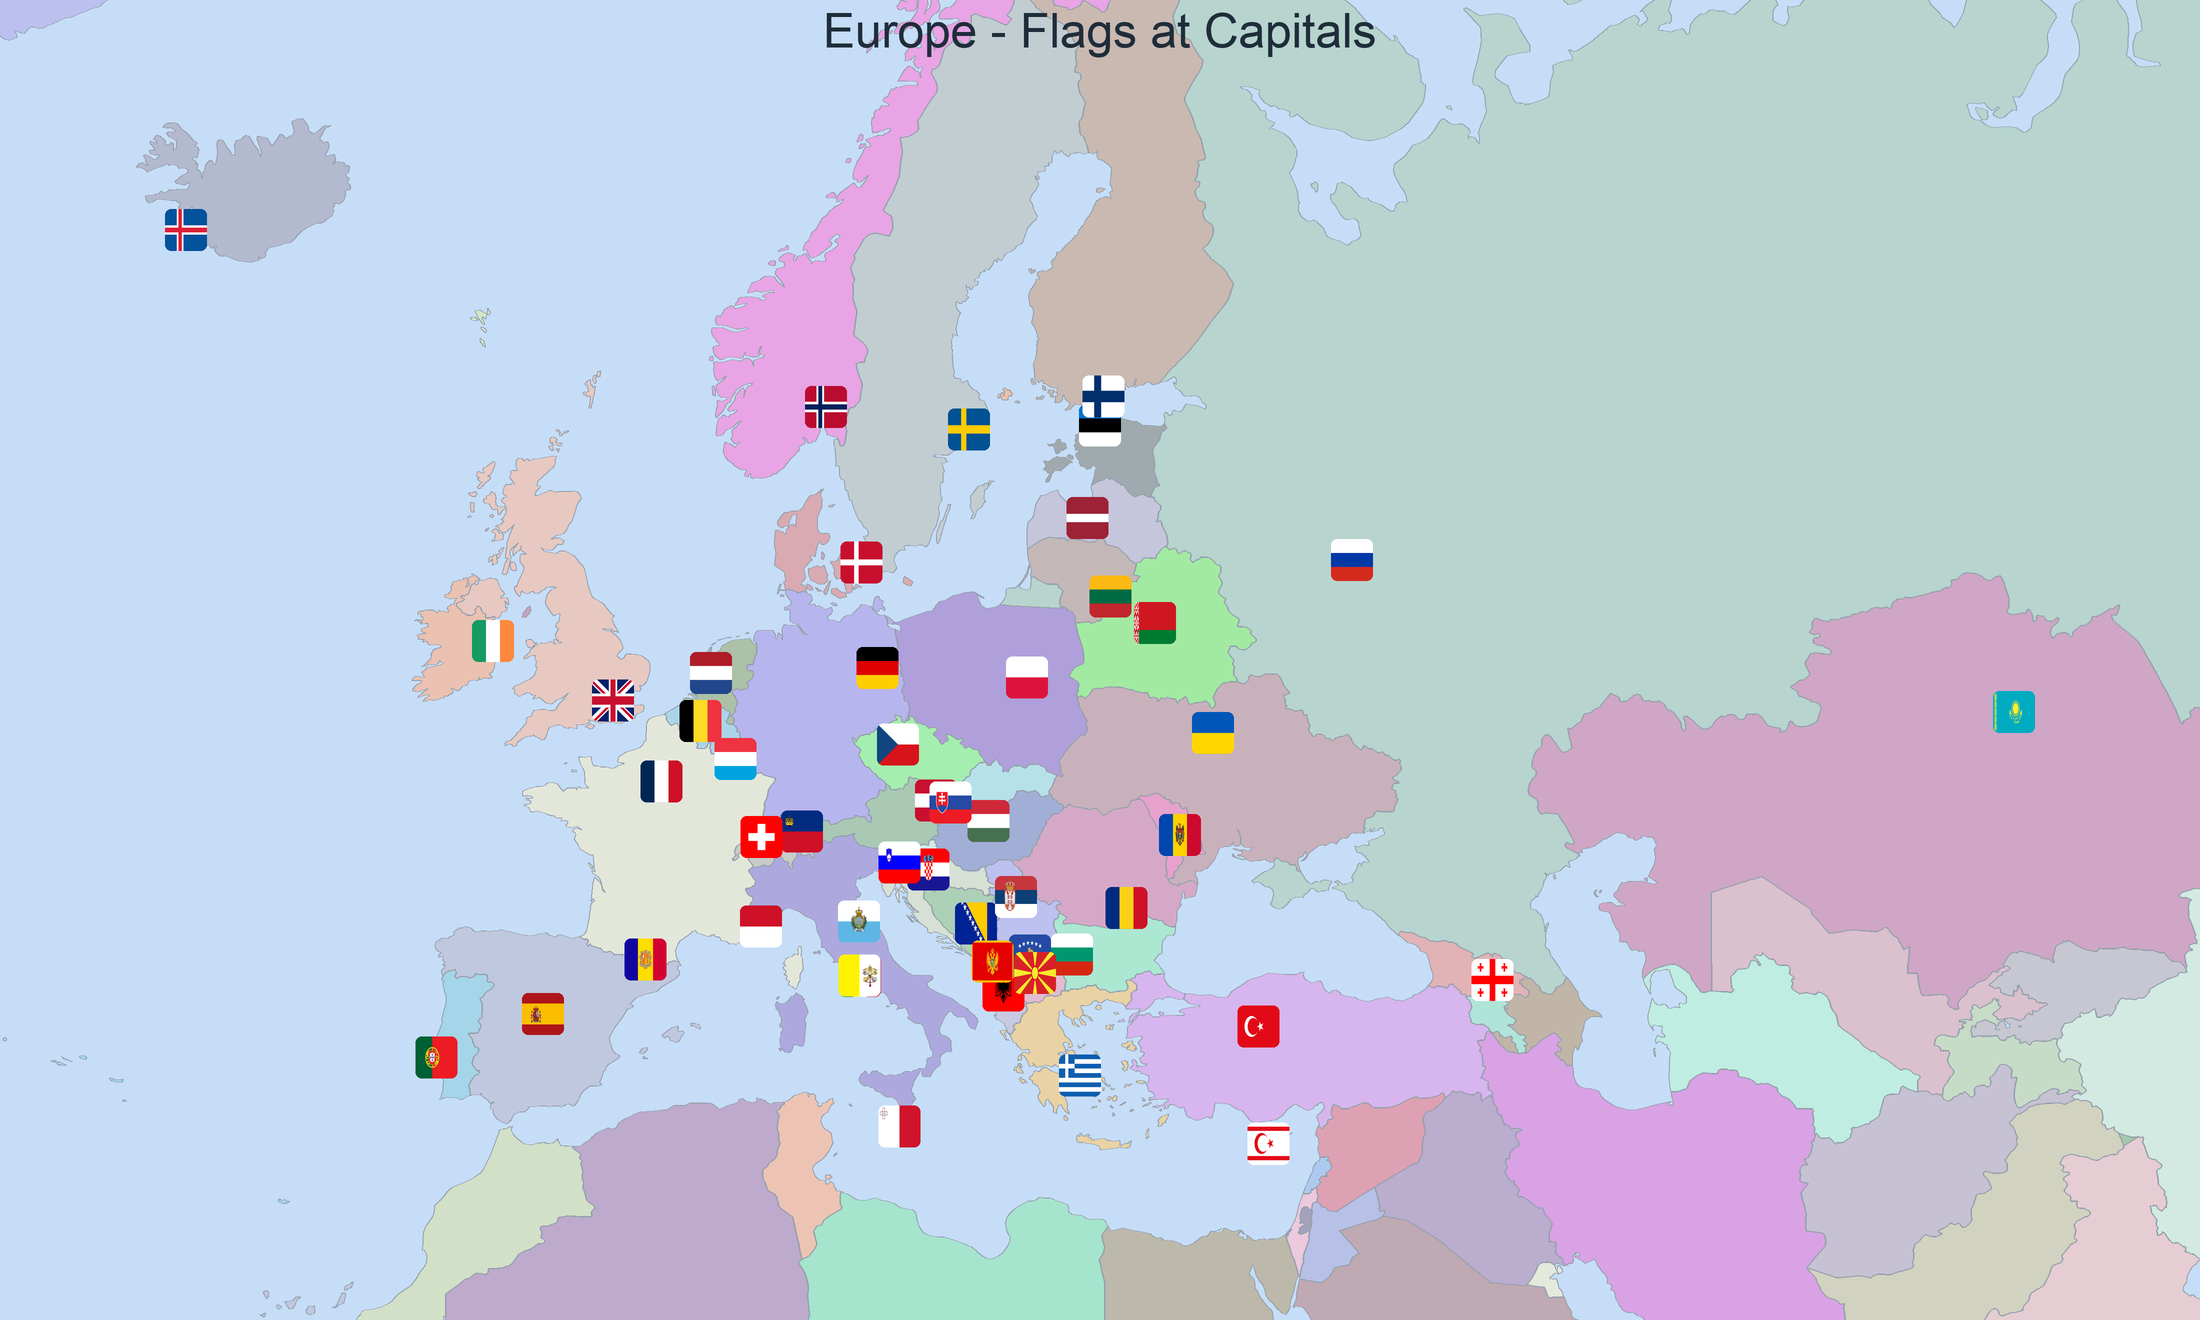

In [13]:
map_path = reg.render.map(
    spec,
    outdir="artifacts/maps",
    size=(2200, 1320),
    marker_px=42,
    show_labels=False,
    show_country_names=False,
    show_capital_names=False,
    show_pick_images=False,
    show_flag_markers=True,
    show_fallback_dots=True,
    allow_live_image_fetch=False,
    flag_marker_size_px=42,
    min_flag_separation_px=0,
)

display_image(map_path)



### Europe with one selected person per country

This can be slower because it selects people and renders portraits. Uncomment and run when needed.


In [15]:
# PORTRAIT_TYPE = "sports"  # options depend on your selector, e.g. "sports" or "musicians"
# person_type = PORTRAIT_TYPE if PORTRAIT_TYPE == "musicians" else "sportsperson"
# N_COUNTRIES = 15
#
# countries = reg.geo.run("europe_countries_flags", min_pop=2_000_000)
# top_countries = sorted(countries, key=lambda c: c.population or 0, reverse=True)[:N_COUNTRIES]
#
# picks = {}
# for country in top_countries:
#     people = reg.geo.run(
#         "famous_by_country",
#         country_qid=country.qid,
#         category=PORTRAIT_TYPE,
#         limit_candidates=60,
#         days=90,
#         score="blended",
#     )
#     best = people[0] if people else None
#     if best:
#         picks[country.qid] = {
#             "qid": best.qid,
#             "label": best.name,
#             "image_url": best.image_url,
#         }
#
# portrait_paths = render_portraits_for_picks(
#     picks,
#     subject_type=person_type,
#     outdir=f"artifacts/europe_{PORTRAIT_TYPE}_portraits",
# )
#
# def image_from_pick_path(country, pick):
#     path = portrait_paths.get(country.qid)
#     return {"path": path} if path else None
#
# spec = countries_to_mapspec(
#     top_countries,
#     title=f"Europe — Notable {PORTRAIT_TYPE.title()} by Country",
#     region_key="europe_flags",
#     picks=picks,
#     image_from_pick=image_from_pick_path,
#     label_fn=label_country_plus_pick,
# )
#
# map_path = reg.render.map(
#     spec,
#     outdir="artifacts/maps",
#     size=(2200, 1320),
#     marker_px=64,
#     show_labels=True,
#     show_country_names=True,
#     show_capital_names=False,
#     show_pick_images=True,
#     pick_image_size_px=56,
# )
#
# print("Map:", map_path)
# display_image(map_path)


## 4. Great-circle flight path

This uses the graph interface to parse a natural-language request, build a map spec, and render a labeled route.


flag_stats: {'markers': 2, 'has_flag_url': 0, 'thumb_resolved': 0, 'flag_loaded': 0, 'flag_drawn': 0, 'flag_skipped_too_close': 0, 'fallback_dot': 2}
Answer: OK
Artifact path: artifacts/maps/Flight Path_ Rome_ GA _ Rome_ Italy __5_038 mi_.png


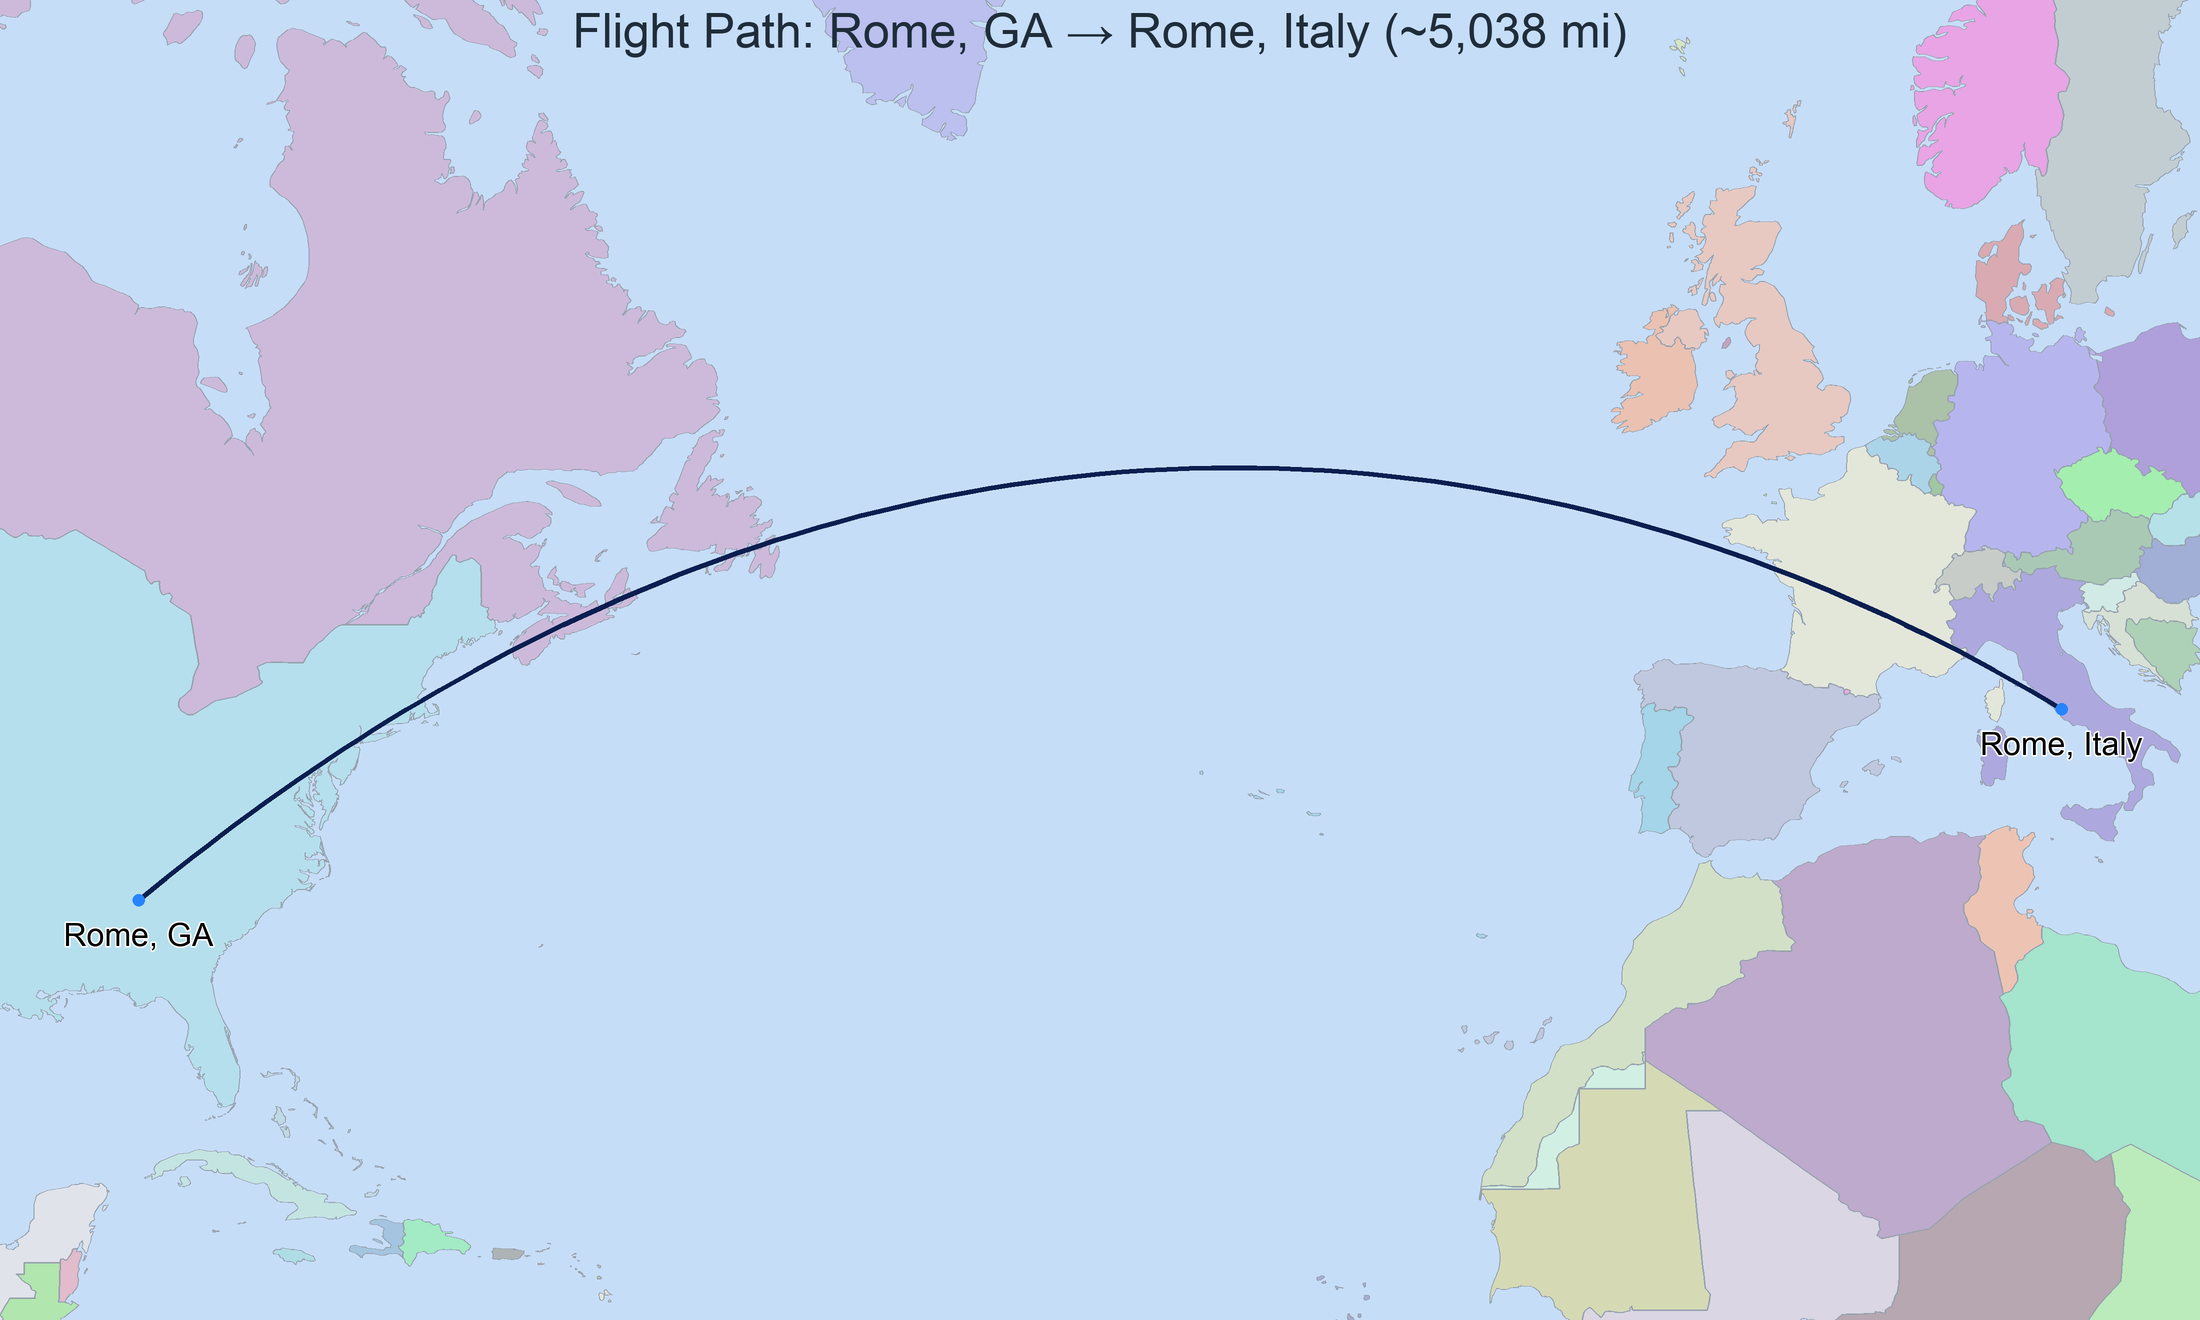

In [16]:
question = "Show me the flight path from Rome, GA to Rome, Italy"

artifact = reg.graphs.geo.invoke({"question": question})

print("Answer:", artifact.get("answer"))
print("Artifact path:", artifact.get("artifact_path"))

display_image(artifact["artifact_path"])


## Notes for maintenance

Heavy generation cells can use a lot of memory in VSCode/Jupyter. For large poster runs:

- Start with 10 or 20 items.
- Use `skip_existing=True`.
- Use `batch_size=5`.
- Display only the final artifact, not every generated image.
- Restart the kernel after large SDXL runs if memory grows.
